In [ ]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

C:\Users\Menna\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Menna\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
# read the data 
df = pd.read_csv('student_performance_prediction_dataset-2.csv') 


In [4]:
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [5]:
df.shape

(300000, 25)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  str    
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-null  float64

In [7]:
df.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [8]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64

In [9]:
# drop student id column
df.drop('student_id', axis=1, inplace=True)

In [10]:
df.duplicated().sum()

0

In [11]:
df['pass_fail'].value_counts()

pass_fail
Pass    180729
Fail    119271
Name: count, dtype: int64

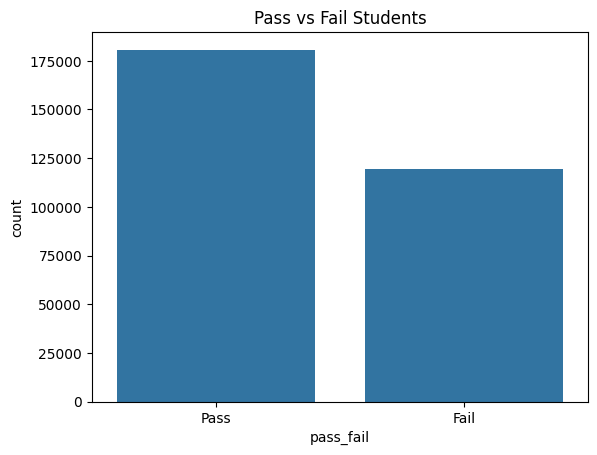

In [12]:
sns.countplot(x='pass_fail', data=df)
plt.title("Pass vs Fail Students")
plt.show()

In [13]:
df['grade_category'].value_counts()

grade_category
F     119267
D      94434
C      61495
B      20910
A       3593
A+       297
Name: count, dtype: int64

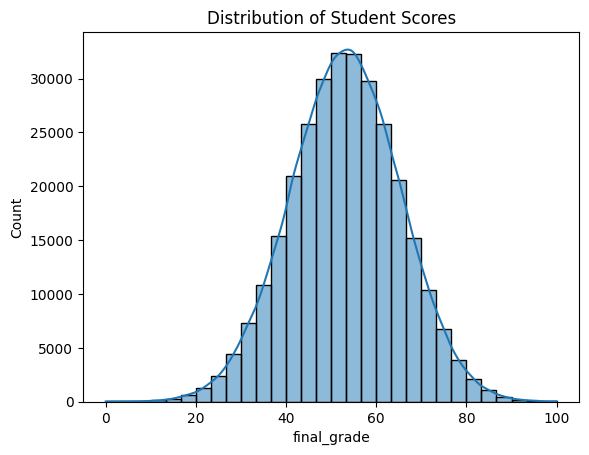

In [14]:
sns.histplot(df['final_grade'], bins=30, kde=True)
plt.title("Distribution of Student Scores")
plt.show()

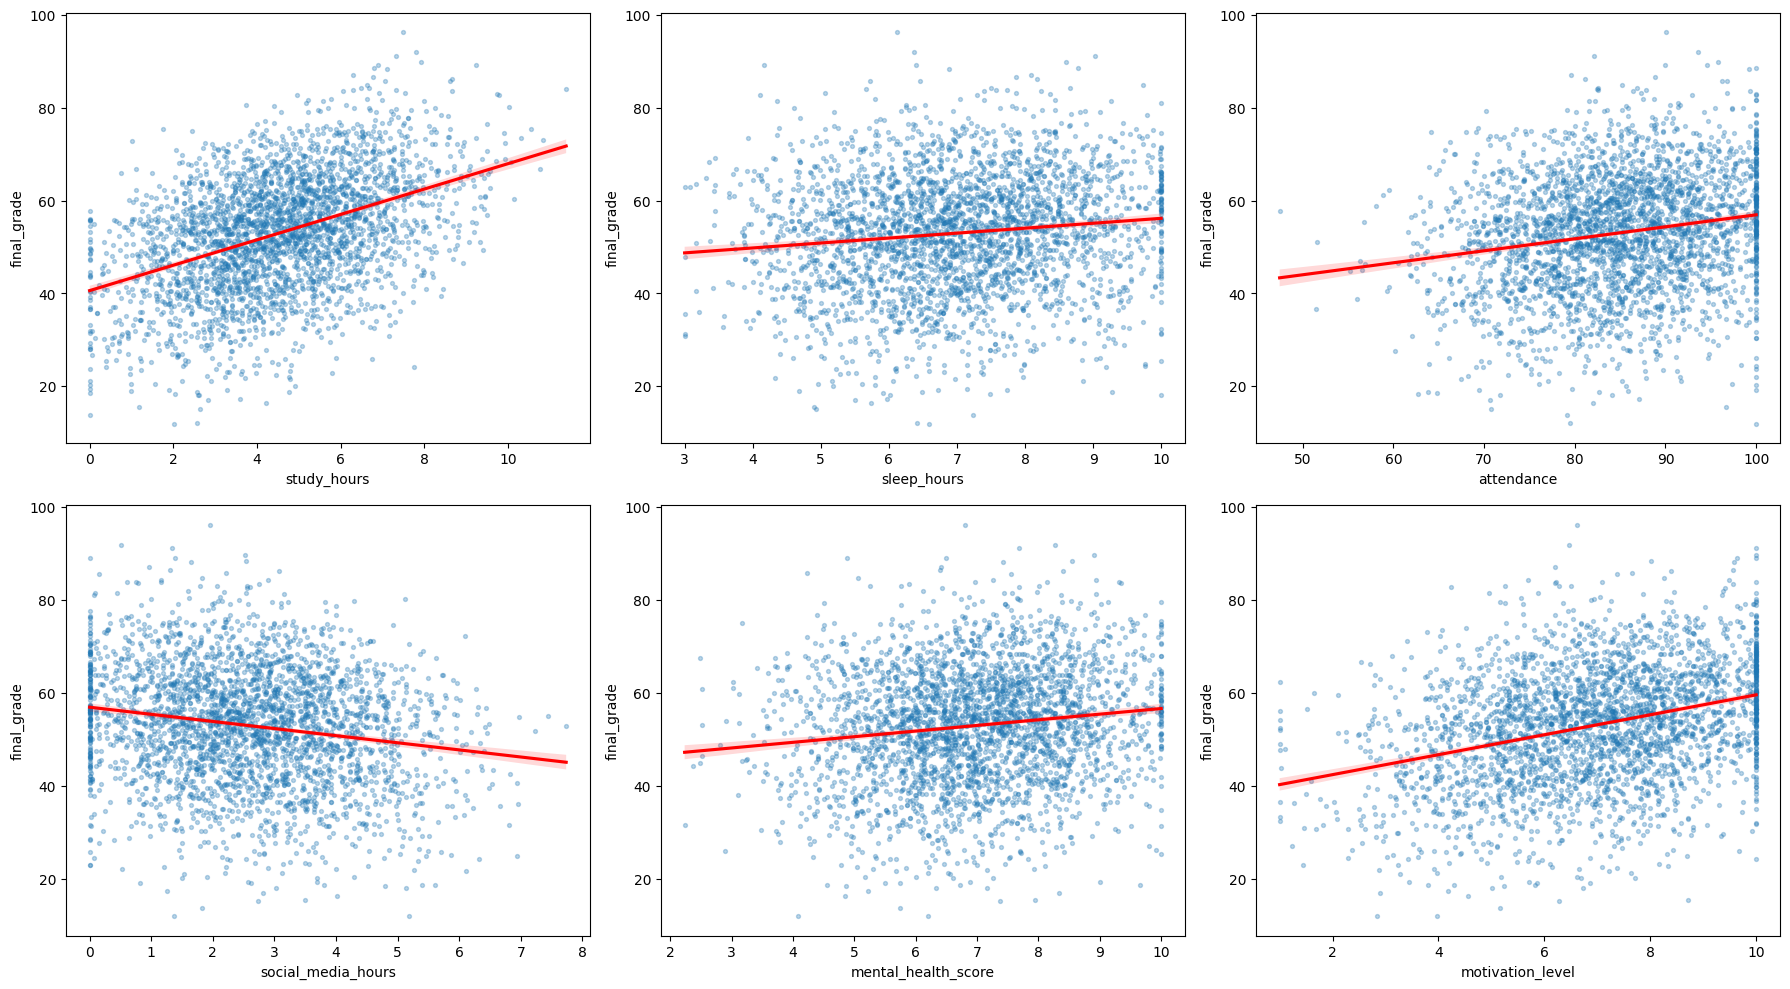

In [15]:
sample = df.sample(n=3000, random_state=42)   

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.regplot(data=sample, x='study_hours', y='final_grade', ax=axes[0,0],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

sns.regplot(data=sample, x='sleep_hours', y='final_grade', ax=axes[0,1],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

sns.regplot(data=sample, x='attendance', y='final_grade', ax=axes[0,2],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

sns.regplot(data=sample, x='social_media_hours', y='final_grade', ax=axes[1,0],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

sns.regplot(data=sample, x='mental_health_score', y='final_grade', ax=axes[1,1],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

sns.regplot(data=sample, x='motivation_level', y='final_grade', ax=axes[1,2],
            scatter_kws={'alpha':0.3, 's': 8}, line_kws={'color': 'red'})

plt.tight_layout()
plt.show()

C:\Users\Menna\AppData\Local\Temp\ipykernel_42956\1458683257.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


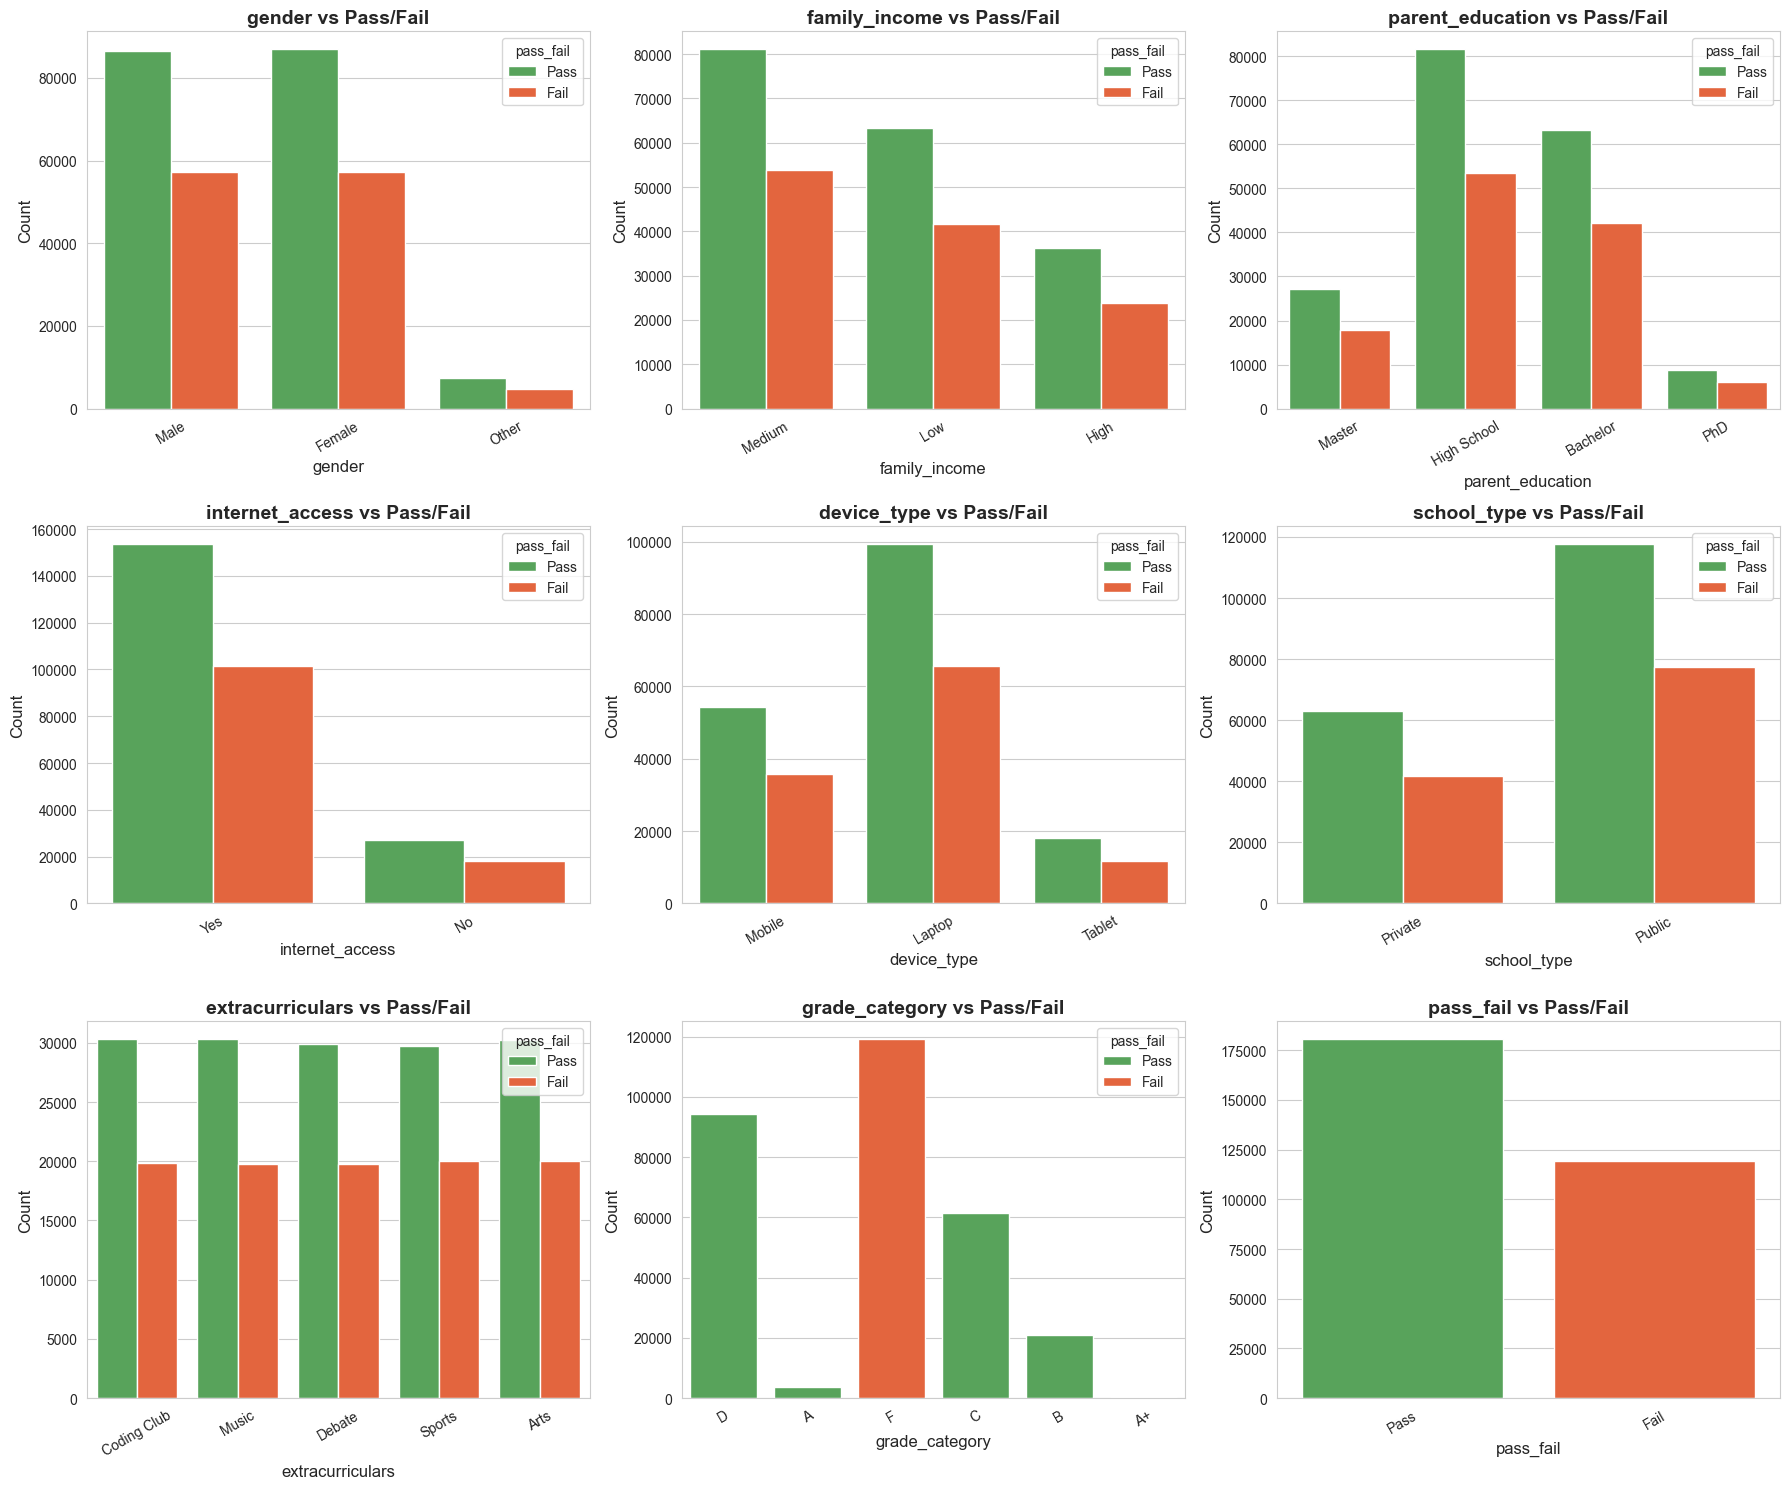

In [24]:
cat_cols = df.select_dtypes(include='object').columns.tolist()


sns.set_style("whitegrid")

n = len(cat_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

palette = ["#4CAF50", "#FF5722"] 

for i, col in enumerate(cat_cols):
    sns.countplot(
        x=col,
        hue='pass_fail',
        data=df,
        ax=axes[i],
        palette=palette
    )
    
    axes[i].set_title(f"{col} vs Pass/Fail", fontsize=14, weight='bold')
    axes[i].tick_params(axis='x', rotation=30)  
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel("Count", fontsize=12)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

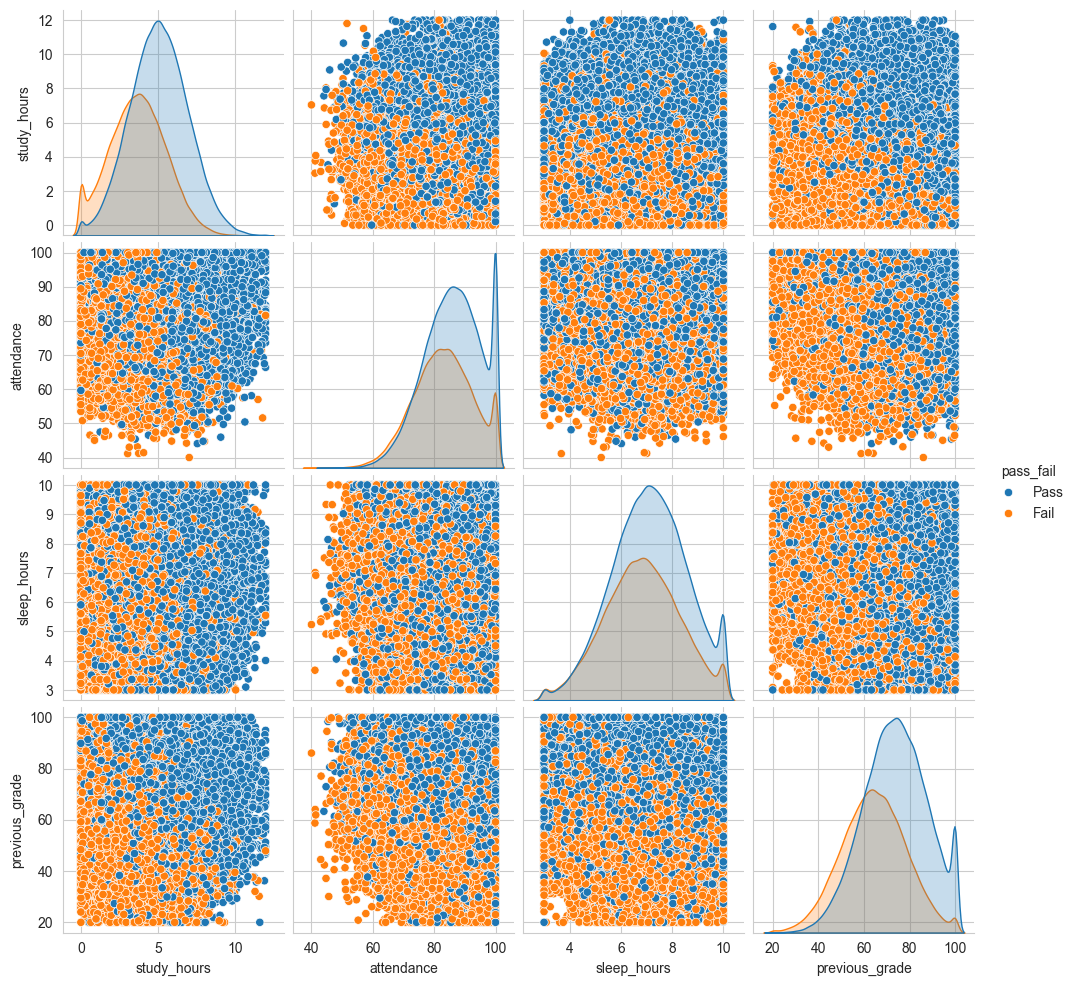

In [20]:
sns.pairplot(df[['study_hours','attendance','sleep_hours','previous_grade','pass_fail']], hue='pass_fail')
plt.show()

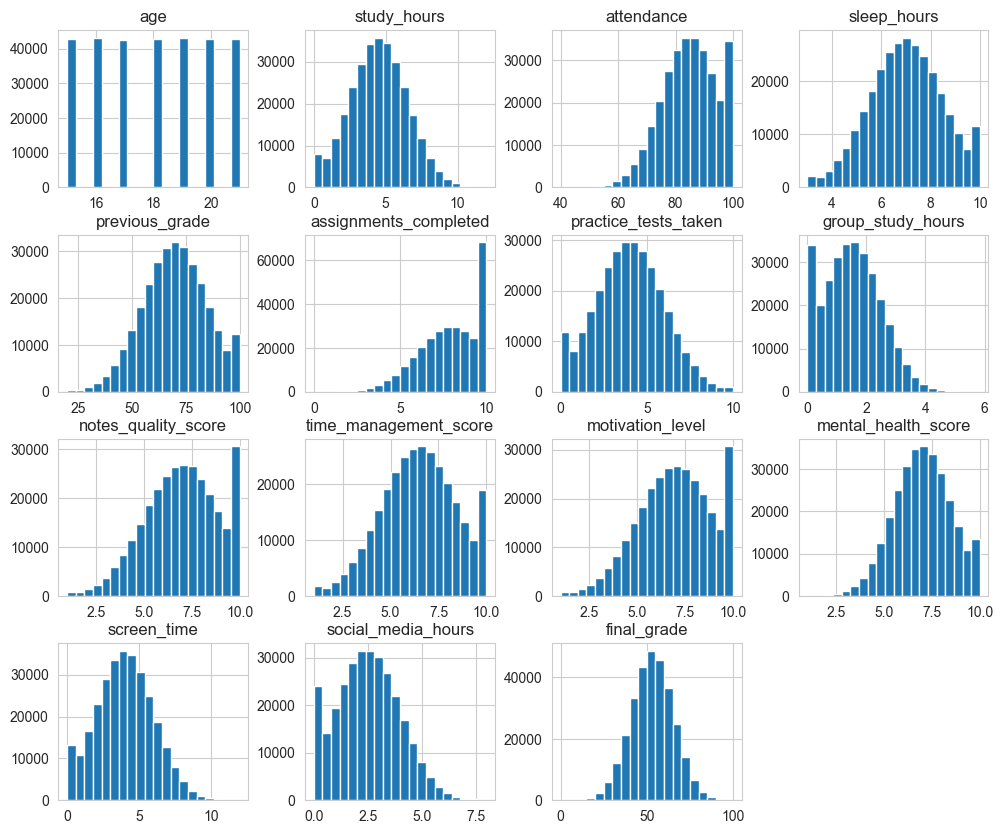

In [18]:
# Histograms of all numerical features to visualize their distributions.

num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].hist(figsize=(12,10), bins=20)
plt.show()

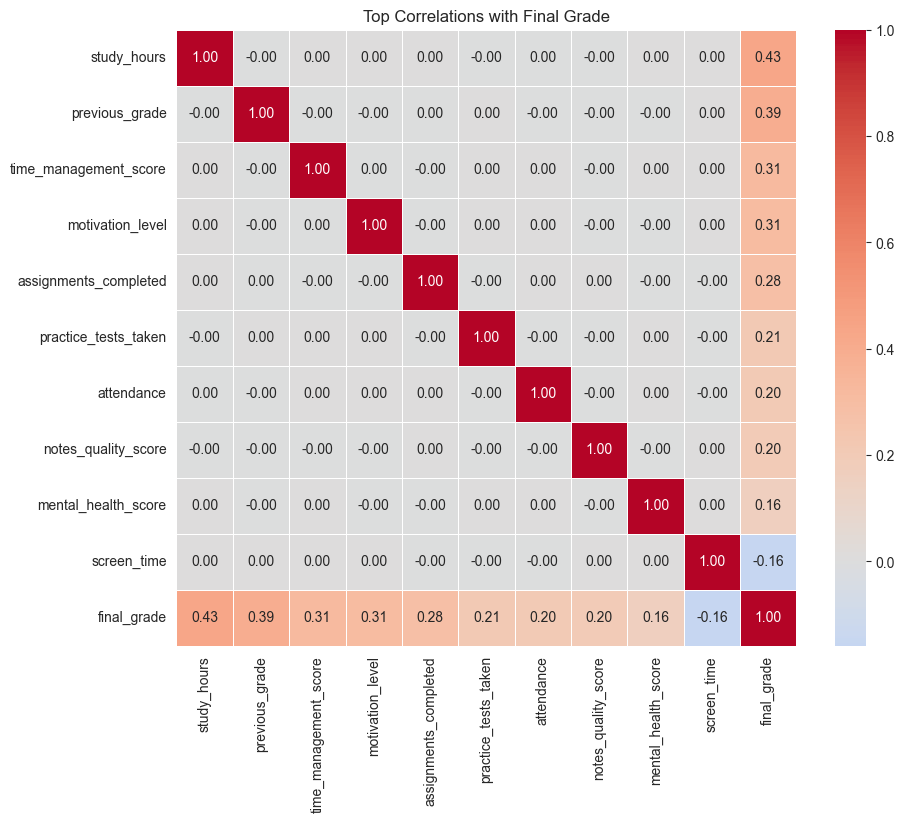

In [23]:
num_df = df.copy()
corr = num_df.corr(numeric_only=True)

if "final_grade" in corr.columns:
    target_corr = corr["final_grade"].drop("final_grade").sort_values(key=np.abs, ascending=False)

top_features = target_corr.index.tolist()[:10] + ["final_grade"]
subset = corr.loc[top_features, top_features]

plt.figure(figsize=(10, 8))

sns.heatmap(subset, 
            annot=True,       
            fmt=".2f",       
            cmap='coolwarm',   
            center=0,         
            linewidths=0.5)   

plt.title("Top Correlations with Final Grade")
plt.show()